# Lab02 — Triagem profunda

Notebook da entrega do Marco 1 (Lab02). As respostas e a leitura dos
resultados estão em `lab2_README.md`; a ficha de arquitetura, em
`lab2_ARQUITETURA.md`.

**Como executar.** As fotos do cliente não fazem parte do repositório. O
notebook lê a pasta de dados e a pasta de trabalho indicadas no `.env` da raiz
deste repositório (modelo em `.env.example`), e só reexecuta na máquina que
tem esses dados. As saídas versionadas mostram apenas contagens, métricas e
gráficos em SVG; nenhuma foto, nome de arquivo ou caminho é exibido.

**Seções:** 1. Configuração · 2. Concordância entre rotuladores (C3) ·
3. Partição sem vazamento (C4)

## 1. Configuração

In [2]:
# Configuração: versões e impressões digitais dos artefatos de entrada.
# Nenhum caminho é exibido (decisão E15): só versões e SHA-256.
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
import torch
import torchvision

from meter_reader.config import get_data_dir, get_work_dir
from training.build_manifest import MANIFEST_NAME, file_sha256
from training.build_sample import SAMPLE_NAME
from training.labels import MASKED, SCENE_METER_ONLY

# Rótulos versionados neste repositório (o notebook roda a partir de lab-02/)
LABELS_PATH = Path("rotulos/lab2_rotulos.csv")
assert LABELS_PATH.is_file(), "Execute o notebook a partir da pasta lab-02/."

WORK_DIR = get_work_dir()   # valida o .env; não exibe o caminho
DATA_DIR = get_data_dir()

print(f"Python       {sys.version.split()[0]}")
print(f"PyTorch      {torch.__version__} | torchvision {torchvision.__version__}")
print(f"scikit-learn {sklearn.__version__} | numpy {np.__version__} | pandas {pd.__version__}")
print(f"GPU (CUDA)   {'sim' if torch.cuda.is_available() else 'não'}")
print()
# Impressões digitais: ligam os resultados aos mesmos dados da ET2
print(f"SHA-256 manifesto: {file_sha256(WORK_DIR / MANIFEST_NAME)}")
print(f"SHA-256 amostra:   {file_sha256(WORK_DIR / SAMPLE_NAME)}")
print(f"SHA-256 rótulos:   {file_sha256(LABELS_PATH)}")

Python       3.11.4
PyTorch      2.14.1+cu126 | torchvision 0.29.1+cu126
scikit-learn 1.9.1 | numpy 2.4.6 | pandas 3.0.6
GPU (CUDA)   sim

SHA-256 manifesto: 56467c02e64f41b6c495987e4cec4c0216dc1e38e5644ae65bceca8d2199b28a
SHA-256 amostra:   a6ced4666242f3c5832d5109c1fdc9289bbc754a693a9252971ed5259c417796
SHA-256 rótulos:   b901c05c2b5e6b89fba53adf512681a8d2507ef1aa9c2597033b6f84069c2f2e


## 2. Concordância entre rotuladores (C3)

Kappa de Cohen nas 50 fotos rotuladas às cegas pelo R1 e pelo R2, com os
rótulos brutos, antes da adjudicação. Por classe: um contra o resto. A
legibilidade é comparada só nas fotos que os dois rotularam como medidor.
Intervalo de 95% por bootstrap percentil sobre as fotos (2.000 reamostragens).
Critério da rubrica: kappa abaixo de 0,6 indica definição ambígua.

In [3]:
# C3: kappa de Cohen nas 50 fotos às cegas, com os rótulos brutos do R1 e do R2
import warnings

from sklearn.metrics import cohen_kappa_score

raw = pd.read_csv(LABELS_PATH, dtype=str, keep_default_na=False)
r2 = raw[raw["rotulador"] == "R2"].set_index("nome_arquivo")
r1 = raw[raw["rotulador"] == "R1"].set_index("nome_arquivo").loc[r2.index]  # mesmas fotos
assert len(r2) == 50 and r2.index.is_unique


def scene4(df: pd.DataFrame) -> np.ndarray:
    """Cena em 4 classes: o tipo para medidores e 'outros' para o resto."""
    return np.where(df["cena_n1"] == "outros", "outros", df["cena_n2"]).astype(str)


def kappa(y1: np.ndarray, y2: np.ndarray) -> float:
    """Kappa de Cohen; indefinido (nan) se só uma classe aparece nos dois."""
    if len(set(y1) | set(y2)) < 2:
        return float("nan")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # avisos de divisão por zero viram nan
        return float(cohen_kappa_score(y1, y2))


def bootstrap_ci(y1, y2, n_boot=2000, seed=0):
    """IC de 95% percentil; descarta reamostragens com kappa indefinido."""
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(y1), size=(n_boot, len(y1)))
    values = np.array([kappa(y1[i], y2[i]) for i in idx])
    valid = values[~np.isnan(values)]
    low, high = np.percentile(valid, [2.5, 97.5]) if len(valid) else (np.nan, np.nan)
    return low, high, len(valid)


s1, s2 = scene4(r1), scene4(r2)
both_meter = (r1["cena_n1"] == "medidor").to_numpy() & (r2["cena_n1"] == "medidor").to_numpy()

variables = {
    "Medidor × outros": (r1["cena_n1"].to_numpy(), r2["cena_n1"].to_numpy()),
    "Cena (4 classes)": (s1, s2),
    **{f"Cena: {c} × resto": (s1 == c, s2 == c)
       for c in ("digital", "ciclometrico", "indeterminado", "outros")},
    "Legibilidade (medidores)": (r1["legibilidade"].to_numpy()[both_meter],
                                 r2["legibilidade"].to_numpy()[both_meter]),
}

rows = []
for name, (y1, y2) in variables.items():
    y1, y2 = np.asarray(y1), np.asarray(y2)
    k = kappa(y1, y2)
    low, high, n_valid = bootstrap_ci(y1, y2)
    rows.append({
        "Variável": name,
        "Fotos": len(y1),
        # Casos da classe marcados por cada rotulador (só nas linhas um-contra-o-resto)
        "Casos R1/R2": f"{int(y1.sum())}/{int(y2.sum())}" if y1.dtype == bool else "—",
        "Concordância (%)": round(100 * float(np.mean(y1 == y2)), 1),
        "Kappa": round(k, 3),
        "IC 95%": f"[{low:.2f}; {high:.2f}]",
        "Reamostragens válidas": n_valid,
        "Kappa ≥ 0,6": "sim" if k >= 0.6 else ("—" if np.isnan(k) else "NÃO"),
    })

c3 = pd.DataFrame(rows).set_index("Variável")
c3

,Fotos,Casos R1/R2,Concordância (%),Kappa,IC 95%,Reamostragens válidas,"Kappa ≥ 0,6"
Variável,,,,,,,
Medidor × outros,50,—,100.0,1.000,[1.00; 1.00],1958,sim
Cena (4 classes),50,—,98.0,0.947,[0.80; 1.00],2000,sim
Cena: digital × resto,50,38/39,98.0,0.944,[0.79; 1.00],2000,sim
Cena: ciclometrico × resto,50,8/7,98.0,0.922,[0.70; 1.00],1999,sim
Cena: indeterminado × resto,50,0/0,100.0,NaN,[nan; nan],0,—
Cena: outros × resto,50,4/4,100.0,1.000,[1.00; 1.00],1958,sim
Legibilidade (medidores),46,—,97.8,0.911,[0.65; 1.00],2000,sim


## 3. Partição sem vazamento (C4)

Partição cronológica por lote: treino 20/05 e 21/05, validação 22/05, teste
03/07. A prova usa todas as imagens e todas as linhas do BaseExtracao de cada
lote, e não só as fotos rotuladas. Só contagens são exibidas.

- **Foto e leitura:** a chave do BaseExtracao é a foto (uma foto por linha).
  O código de 20 dígitos é único por arquivo e o sufixo `_NNN` não agrupa
  fotos de uma mesma leitura (medição da ET1), então o identificador de
  leitura coincide com o da foto.
- **Medidor:** contado de duas formas. *Com foto*: o número esperado das
  fotos pareadas, que são os dados que os modelos veem. *No CSV inteiro*:
  todas as linhas do BaseExtracao, com ou sem foto, inclusive todas as partes
  dos números compostos.

In [4]:
# C4: nenhuma foto, leitura ou medidor aparece em dois conjuntos
from itertools import combinations

from meter_reader.extraction import read_extraction
from training.build_sample import assign_sets

manifest = pd.read_csv(WORK_DIR / MANIFEST_NAME, dtype=str, keep_default_na=False)
set_of_lot = assign_sets(set(manifest["lote"]))  # mesma função que gerou a partição
manifest["conjunto"] = manifest["lote"].map(set_of_lot)

SUBSETS = ("treino", "validacao", "teste")
ids = {s: {} for s in SUBSETS}

# Fotos (= leituras) e medidores com foto: o que os modelos veem
for subset in SUBSETS:
    part = manifest[manifest["conjunto"] == subset]
    ids[subset]["Fotos (= leituras)"] = set(part["arquivo"])
    ids[subset]["Medidores com foto"] = set(part["numero_esperado"]) - {""}

# Medidores no CSV inteiro: todas as linhas e todas as partes dos números
for subset in SUBSETS:
    ids[subset]["Medidores no CSV (todas as partes)"] = set()
for lot_dir in sorted(p for p in DATA_DIR.iterdir() if p.is_dir()):
    (csv_path,) = lot_dir.glob("BaseExtracao_*.csv")  # exatamente um por lote (E16)
    batch = read_extraction(csv_path)
    subset = set_of_lot[batch.batch_date.isoformat()]
    for row in batch.rows:
        ids[subset]["Medidores no CSV (todas as partes)"].update(row.meter_numbers)

LABELS = list(ids["treino"])
pairs = list(combinations(SUBSETS, 2))

sizes = pd.DataFrame(
    {label: [len(ids[s][label]) for s in SUBSETS] for label in LABELS},
    index=pd.Index(SUBSETS, name="Conjunto"),
)
overlaps = pd.DataFrame(
    {label: [len(ids[a][label] & ids[b][label]) for a, b in pairs] for label in LABELS},
    index=pd.Index([f"{a} × {b}" for a, b in pairs], name="Par"),
)

print("Identificadores distintos por conjunto")
display(sizes)
print("Identificadores em comum entre conjuntos")
display(overlaps)

Identificadores distintos por conjunto


,Fotos (= leituras),Medidores com foto,Medidores no CSV (todas as partes)
Conjunto,,,
treino,6285,5858,7737
validacao,3063,2821,3600
teste,2992,2795,3867


Identificadores em comum entre conjuntos


,Fotos (= leituras),Medidores com foto,Medidores no CSV (todas as partes)
Par,,,
treino × validacao,0,0,6
treino × teste,0,0,2
validacao × teste,0,0,1


## 4. O modelo de triagem (B1 e B2)

Espinha dorsal pré-treinada no ImageNet, sem o classificador original, mais
pooling médio global e duas cabeças lineares: cena (3 logits) e legibilidade
(1 logit). Duas espinhas são comparadas pelo protocolo: MobileNetV3-Large e
EfficientNet-B0. A tabela de formas usa uma foto real da base, pré-processada
como na inferência (realce fixo e proporção 3:4 mantida), nas duas
resoluções do protocolo.

In [5]:
# B1: tabela de formas bloco a bloco, com uma foto real nas duas resoluções
from meter_reader.preprocess import preprocess
from meter_reader.triage import BACKBONES, TriageModel
from training.labels import load_labeled_photos

photos = load_labeled_photos(LABELS_PATH)  # treino e validação; o teste fica lacrado
sample_path = photos[0].path               # primeira em ordem de pseudônimo; nunca exibida
inputs = {
    "nativa": preprocess(sample_path).unsqueeze(0),
    "224 px": preprocess(sample_path, 224).unsqueeze(0),
}


def fmt(shape) -> str:
    """Forma sem a dimensão do lote, no formato C × A × L."""
    return " × ".join(str(d) for d in shape) if shape else "1"


def shape_rows(model: TriageModel, x: torch.Tensor) -> list[tuple[str, str]]:
    rows = [("entrada", fmt(x.shape[1:]))]
    hooks = [
        block.register_forward_hook(
            lambda _m, _i, out, name=f"features.{i}": rows.append((name, fmt(out.shape[1:])))
        )
        for i, block in enumerate(model.features)
    ]
    with torch.no_grad():
        z = model.embed(x)
        scene, legibility = model.heads(z)
    for h in hooks:
        h.remove()
    rows += [
        ("pooling + achatamento", fmt(z.shape[1:])),
        ("cabeça de cena (logits)", fmt(scene.shape[1:])),
        ("cabeça de legibilidade (logit)", fmt(legibility.shape[1:])),
    ]
    return rows


models = {name: TriageModel(name).eval() for name in BACKBONES}  # pesos do ImageNet
for name, model in models.items():
    table = {res: dict(shape_rows(model, x)) for res, x in inputs.items()}
    print(f"\n{name}")
    display(pd.DataFrame(table).rename_axis("Camada"))


mobilenet_v3_large


,nativa,224 px
Camada,,
entrada,3 × 480 × 360,3 × 299 × 224
features.0,16 × 240 × 180,16 × 150 × 112
features.1,16 × 240 × 180,16 × 150 × 112
features.2,24 × 120 × 90,24 × 75 × 56
features.3,24 × 120 × 90,24 × 75 × 56
features.4,40 × 60 × 45,40 × 38 × 28
features.5,40 × 60 × 45,40 × 38 × 28
features.6,40 × 60 × 45,40 × 38 × 28
features.7,80 × 30 × 23,80 × 19 × 14



efficientnet_b0


,nativa,224 px
Camada,,
entrada,3 × 480 × 360,3 × 299 × 224
features.0,32 × 240 × 180,32 × 150 × 112
features.1,16 × 240 × 180,16 × 150 × 112
features.2,24 × 120 × 90,24 × 75 × 56
features.3,40 × 60 × 45,40 × 38 × 28
features.4,80 × 30 × 23,80 × 19 × 14
features.5,112 × 30 × 23,112 × 19 × 14
features.6,192 × 15 × 12,192 × 10 × 7
features.7,320 × 15 × 12,320 × 10 × 7


In [6]:
# B2: parâmetros totais e treináveis, em extração e em ajuste fino
def count(model: TriageModel) -> tuple[int, int]:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


rows = []
for name in BACKBONES:
    fine_tune = TriageModel(name)                 # ajuste fino: tudo treinável
    total, trainable_ft = count(fine_tune)
    extraction = TriageModel(name)
    extraction.freeze_backbone()                  # extração: só as cabeças
    _, trainable_fx = count(extraction)
    rows.append({
        "Espinha dorsal": name,
        "Parâmetros totais": f"{total:,}".replace(",", "."),
        "Treináveis (extração)": f"{trainable_fx:,}".replace(",", "."),
        "Treináveis (ajuste fino)": f"{trainable_ft:,}".replace(",", "."),
        "Razão ajuste fino / extração": f"{trainable_ft / trainable_fx:.0f}×",
    })

b2 = pd.DataFrame(rows).set_index("Espinha dorsal")
b2

,Parâmetros totais,Treináveis (extração),Treináveis (ajuste fino),Razão ajuste fino / extração
Espinha dorsal,,,,
mobilenet_v3_large,2.975.796,3.844,2.975.796,774×
efficientnet_b0,4.012.672,5.124,4.012.672,783×


## 5. Sanidade (D1 e D2)

**D1.** Perda inicial com as cabeças aleatórias e a espinha congelada,
comparada à perda de uma saída uniforme (logits nulos). Sem pesos e sem
indeterminados, essa referência é ln 3 para a cena e ln 2 para a
legibilidade; com o indeterminado (perda parcial) e com os pesos do
protocolo, ela é calculada pela própria função de perda.

In [7]:
# D1: perda inicial com cabeças aleatórias, comparada à saída uniforme
import math

from training import triage_loss as tl

torch.manual_seed(0)
# 32 fotos de treino da amostra aleatória (sem os zeros do estresse)
d1_photos = [p for p in photos if p.subset == "treino" and p.role != "estresse_zero"][:32]
x = torch.stack([preprocess(p.path, 224) for p in d1_photos])
scene_t = torch.tensor([p.scene for p in d1_photos])
leg_t = torch.tensor([p.illegible for p in d1_photos])

settings = {
    "sem pesos": (torch.ones(tl.N_SCENE + 1), torch.tensor(1.0)),
    "com os pesos do protocolo": (tl.scene_weights(scene_t), tl.legibility_pos_weight(leg_t)),
}

rows = []
for name in BACKBONES:
    model = TriageModel(name)
    model.freeze_backbone()
    model.eval()
    with torch.no_grad():
        scene_logits, leg_logits = model(x)
        for label, (w, pw) in settings.items():
            rows.append({
                "Espinha dorsal": name,
                "Perda": label,
                "Cena obtida": tl.scene_loss(scene_logits, scene_t, w).item(),
                "Cena, saída uniforme": tl.scene_loss(torch.zeros_like(scene_logits), scene_t, w).item(),
                "Legibilidade obtida": tl.legibility_loss(leg_logits, leg_t, pw).item(),
                "Legibilidade, saída uniforme": tl.legibility_loss(torch.zeros_like(leg_logits), leg_t, pw).item(),
            })

d1 = pd.DataFrame(rows).set_index(["Espinha dorsal", "Perda"]).round(3)
print(f"ln 3 = {math.log(3):.3f} | ln 2 = {math.log(2):.3f}")
print(f"Fotos: {len(d1_photos)} | indeterminados: {int((scene_t == -1).sum())} | "
      f"outros: {int((scene_t == 2).sum())} | ilegíveis: {int((leg_t == 1).sum())}")
d1

ln 3 = 1.099 | ln 2 = 0.693
Fotos: 32 | indeterminados: 4 | outros: 3 | ilegíveis: 7


Cena obtida  \
Espinha dorsal     Perda                                    
mobilenet_v3_large sem pesos                        1.213   
                   com os pesos do protocolo        1.140   
efficientnet_b0    sem pesos                        1.044   
                   com os pesos do protocolo        1.093   

                                              Cena, saída uniforme  \
Espinha dorsal     Perda                                             
mobilenet_v3_large sem pesos                                 1.012   
                   com os pesos do protocolo                 1.032   
efficientnet_b0    sem pesos                                 1.012   
                   com os pesos do protocolo                 1.032   

                                              Legibilidade obtida  \
Espinha dorsal     Perda                                            
mobilenet_v3_large sem pesos                                0.707   
                   com os pesos do protocolo                1.069   
efficientnet_b0    sem pesos                                0.657   
                   com os pesos do protocolo                1.036   

                                              Legibilidade, saída uniforme  
Espinha dorsal     Perda                                                    
mobilenet_v3_large sem pesos                                         0.693  
                   com os pesos do protocolo                         1.052  
efficientnet_b0    sem pesos                                         0.693  
                   com os pesos do protocolo                         1.052

**D2.** Sobreajuste de 16 fotos reais do treino (3 de outros, 3 indeterminadas,
3 ciclométricas e 7 digitais), no modo de extração de características e com
os hiperparâmetros do protocolo (AdamW, taxa 1e-3, decaimento 1e-4, lote
completo, 300 épocas). Critério: perda total abaixo de 0,05 e acerto de 100%
nas 16 fotos.

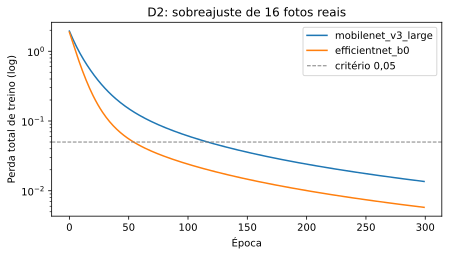

,Perda inicial,Perda final,Acerto de cena,Acerto de legibilidade
Espinha dorsal,,,,
mobilenet_v3_large,1.943,0.0136,16/16,13/13
efficientnet_b0,1.876,0.0058,16/16,13/13


In [8]:
# D2: sobreajuste de 16 fotos reais, só com as cabeças (espinha congelada)
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg")  # gráficos vetoriais (regra do repositório)

pool = [p for p in photos if p.subset == "treino" and p.role != "estresse_zero"]
quota = {2: 3, SCENE_METER_ONLY: 3, 1: 3, 0: 7}  # outros, indeterminado, ciclométrico, digital
d2_photos = [p for scene, n in quota.items() for p in [q for q in pool if q.scene == scene][:n]]
assert len(d2_photos) == 16

scene_t = torch.tensor([p.scene for p in d2_photos])
leg_t = torch.tensor([p.illegible for p in d2_photos])
weights, pos_weight = tl.scene_weights(scene_t), tl.legibility_pos_weight(leg_t)
x = torch.stack([preprocess(p.path, 224) for p in d2_photos])

EPOCHS = 300
curves, rows = {}, []
for name in BACKBONES:
    torch.manual_seed(0)
    model = TriageModel(name)
    model.freeze_backbone()
    with torch.no_grad():
        z = model.embed(x)  # características calculadas uma vez
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad], lr=1e-3, weight_decay=1e-4
    )
    history = []
    for _ in range(EPOCHS):
        optimizer.zero_grad()
        total, _, _ = tl.triage_loss(*model.heads(z), scene_t, leg_t, weights, pos_weight)
        total.backward()
        optimizer.step()
        history.append(total.item())
    curves[name] = history

    with torch.no_grad():
        scene_logits, leg_logits = model.heads(z)
    predicted = scene_logits.argmax(1)
    exact = scene_t != SCENE_METER_ONLY
    # Indeterminado acerta se a classe prevista for um tipo de medidor (não "outros")
    scene_ok = torch.where(exact, predicted == scene_t, predicted != 2)
    measured = leg_t != MASKED
    leg_ok = (leg_logits[measured] > 0).long() == leg_t[measured]
    rows.append({
        "Espinha dorsal": name,
        "Perda inicial": round(history[0], 3),
        "Perda final": round(history[-1], 4),
        "Acerto de cena": f"{int(scene_ok.sum())}/16",
        "Acerto de legibilidade": f"{int(leg_ok.sum())}/{int(measured.sum())}",
    })

fig, ax = plt.subplots(figsize=(7, 3.5))
for name, history in curves.items():
    ax.plot(history, label=name)
ax.set_yscale("log")
ax.set_xlabel("Época")
ax.set_ylabel("Perda total de treino (log)")
ax.set_title("D2: sobreajuste de 16 fotos reais")
ax.axhline(0.05, linestyle="--", linewidth=1, color="gray", label="critério 0,05")
ax.legend()
plt.show()

d2 = pd.DataFrame(rows).set_index("Espinha dorsal")
d2

## 6. Extração de características × baseline (D3)

Validação por lote deixado de fora (3 dobras: 20/05, 21/05 e 22/05), 3
sementes por configuração, predições fora da dobra. Métrica otimizadora:
média da AP de "outros" e da AP de "ilegível", só na amostra aleatória.
Comparações na ordem fixada no protocolo, com bootstrap pareado:
(1) espinha dorsal a 224 px, empate segue a MobileNetV3-Large;
(2) resolução com a espinha vencedora, empate segue 224 px;
(3) configuração profunda vencedora × baseline, empate segue o profundo.

In [9]:
# D3, etapa 1: características das 261 fotos, com cache na pasta de trabalho
import time

from training.features import FEATURE_SETS, load_or_extract

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CACHE_DIR = WORK_DIR / "caracteristicas"
CACHE_DIR.mkdir(exist_ok=True)

features = {}
for name in FEATURE_SETS:
    start = time.perf_counter()
    features[name] = load_or_extract(photos, name, CACHE_DIR, DEVICE)
    elapsed = time.perf_counter() - start
    print(f"{name:28} {features[name].shape[0]} fotos × {features[name].shape[1]:5} dimensões"
          f"  ({elapsed:6.1f} s)")
print(f"\nDispositivo: {DEVICE}")

baseline_224                 261 fotos ×  1859 dimensões  (   3.2 s)
mobilenet_v3_large_224       261 fotos ×   960 dimensões  (   1.7 s)
mobilenet_v3_large_nativa    261 fotos ×   960 dimensões  (   2.0 s)
efficientnet_b0_224          261 fotos ×  1280 dimensões  (   1.6 s)
efficientnet_b0_nativa       261 fotos ×  1280 dimensões  (   2.2 s)

Dispositivo: cuda


In [12]:
# D3, etapa 2: avaliação de uma configuração (3 sementes) e regra de vitória
from training.cross_validation import EPOCHS, LEARNING_RATE, WEIGHT_DECAY, cross_validate
from training.evaluation import (
    bootstrap_ci, log_losses, optimizing_metric, paired_bootstrap, record_run, targets,
)

SEEDS = (0, 1, 2)
scene_all, ill_all, random_sample = targets(photos)
s_eval, i_eval = scene_all[random_sample], ill_all[random_sample]  # só a amostra aleatória
LABELS_SHA = file_sha256(LABELS_PATH)
results = {}


def evaluate(name: str, train_fraction: float = 1.0) -> dict:
    """Roda as 3 sementes, resume as métricas e grava o registro da execução."""
    per_seed, scene_probs, ill_probs, train_losses = [], [], [], []
    for seed in SEEDS:
        p_s, p_i, folds = cross_validate(features[name], photos, seed, train_fraction, DEVICE)
        scene_probs.append(p_s)
        ill_probs.append(p_i)
        train_losses += [f.final_train_loss for f in folds]
        metric, ap_o, ap_i = optimizing_metric(p_s[random_sample], p_i[random_sample], s_eval, i_eval)
        ll_s, ll_i = log_losses(p_s[random_sample], p_i[random_sample], s_eval, i_eval)
        per_seed.append({"metrica": metric, "ap_outros": ap_o, "ap_ilegivel": ap_i,
                         "ll_cena": ll_s, "ll_legibilidade": ll_i})

    p_scene, p_ill = np.mean(scene_probs, axis=0), np.mean(ill_probs, axis=0)
    low, high, valid = bootstrap_ci(p_scene[random_sample], p_ill[random_sample], s_eval, i_eval)
    seeds_df = pd.DataFrame(per_seed)
    summary = {
        "Métrica (média)": seeds_df["metrica"].mean(),
        "Métrica (desvio)": seeds_df["metrica"].std(ddof=1),
        "AP outros": seeds_df["ap_outros"].mean(),
        "AP ilegível": seeds_df["ap_ilegivel"].mean(),
        "Perda log. cena": seeds_df["ll_cena"].mean(),
        "Perda log. legib.": seeds_df["ll_legibilidade"].mean(),
        "IC 95% (prob. média)": f"[{low:.3f}; {high:.3f}]",
        "Perda final de treino (máx.)": max(train_losses),
    }
    config = {"caracteristicas": name, "fracao_treino": train_fraction, "sementes": list(SEEDS),
              "epocas": EPOCHS, "taxa": LEARNING_RATE, "decaimento": WEIGHT_DECAY,
              "dispositivo": DEVICE, "sha256_rotulos": LABELS_SHA}
    record_run(WORK_DIR, f"d3_{name}_{round(train_fraction * 100)}", config,
               {"por_semente": per_seed, "ic95": [low, high], "reamostragens_validas": valid},
               photos, p_scene, p_ill)
    result = {"p_scene": p_scene, "p_ill": p_ill, "summary": summary}
    if train_fraction == 1.0:
        results[name] = result
    return result


def compare(a: str, b: str, tie_winner: str, step: str) -> tuple[str, dict]:
    """Regra de vitória do protocolo (2.7): bootstrap pareado da diferença A − B."""
    model_a = (results[a]["p_scene"][random_sample], results[a]["p_ill"][random_sample])
    model_b = (results[b]["p_scene"][random_sample], results[b]["p_ill"][random_sample])
    point, low, high, valid = paired_bootstrap(model_a, model_b, s_eval, i_eval)
    if low > 0:
        winner, verdict = a, "vence A"
    elif high < 0:
        winner, verdict = b, "vence B"
    else:
        winner, verdict = tie_winner, f"empate: segue {tie_winner}"
    row = {"Comparação": step, "A": a, "B": b, "Diferença A − B": round(point, 3),
           "IC 95%": f"[{low:.3f}; {high:.3f}]", "Reamostragens válidas": valid,
           "Resultado": verdict}
    return winner, row


def summary_table(names) -> pd.DataFrame:
    return pd.DataFrame({n: results[n]["summary"] for n in names}).T.rename_axis("Configuração")

In [13]:
# Comparação 1 (protocolo): espinha dorsal, as duas a 224 px; empate segue a Large
for name in ("mobilenet_v3_large_224", "efficientnet_b0_224"):
    evaluate(name)

display(summary_table(["mobilenet_v3_large_224", "efficientnet_b0_224"]).round(3))
best_backbone_224, row_1 = compare(
    "mobilenet_v3_large_224", "efficientnet_b0_224",
    tie_winner="mobilenet_v3_large_224", step="1. Espinha dorsal (224 px)",
)
comparisons = [row_1]
display(pd.DataFrame(comparisons).set_index("Comparação"))
print(f"Segue para a comparação 2: {best_backbone_224}")

,Métrica (média),Métrica (desvio),AP outros,AP ilegível,Perda log. cena,Perda log. legib.,IC 95% (prob. média),Perda final de treino (máx.)
Configuração,,,,,,,,
mobilenet_v3_large_224,0.718505,0.032269,0.603454,0.833556,0.898189,0.453516,[0.611; 0.829],0.021783
efficientnet_b0_224,0.685269,0.023793,0.510168,0.86037,0.980767,0.43747,[0.576; 0.817],0.013303


,A,B,Diferença A − B,IC 95%,Reamostragens válidas,Resultado
Comparação,,,,,,
1. Espinha dorsal (224 px),mobilenet_v3_large_224,efficientnet_b0_224,0.027,[-0.080; 0.128],2000,empate: segue mobilenet_v3_large_224


Segue para a comparação 2: mobilenet_v3_large_224


In [14]:
# Comparações 2 e 3 (protocolo), na ordem fixada
# 2. Resolução, só com a espinha vencedora; empate segue 224 px
native = best_backbone_224.replace("_224", "_nativa")
evaluate(native)
best_deep, row_2 = compare(native, best_backbone_224, tie_winner=best_backbone_224,
                           step="2. Resolução (nativa × 224 px)")

# 3. D3: configuração profunda vencedora × baseline; empate segue o profundo
evaluate("baseline_224")
winner_d3, row_3 = compare(best_deep, "baseline_224", tie_winner=best_deep,
                           step="3. Profundo × baseline (D3)")

comparisons = [row_1, row_2, row_3]  # recriada, para não duplicar ao reexecutar
display(summary_table([best_backbone_224, native, "baseline_224"]).round(3))
display(pd.DataFrame(comparisons).set_index("Comparação"))
print(f"Configuração vencedora do D3: {winner_d3}")

,Métrica (média),Métrica (desvio),AP outros,AP ilegível,Perda log. cena,Perda log. legib.,IC 95% (prob. média),Perda final de treino (máx.)
Configuração,,,,,,,,
mobilenet_v3_large_224,0.718505,0.032269,0.603454,0.833556,0.898189,0.453516,[0.611; 0.829],0.021783
mobilenet_v3_large_nativa,0.707144,0.029363,0.549646,0.864642,0.997802,0.385739,[0.597; 0.828],0.02502
baseline_224,0.463554,0.01238,0.163079,0.764028,2.036089,0.710292,[0.403; 0.556],0.013106


,A,B,Diferença A − B,IC 95%,Reamostragens válidas,Resultado
Comparação,,,,,,
1. Espinha dorsal (224 px),mobilenet_v3_large_224,efficientnet_b0_224,0.027,[-0.080; 0.128],2000,empate: segue mobilenet_v3_large_224
2. Resolução (nativa × 224 px),mobilenet_v3_large_nativa,mobilenet_v3_large_224,-0.007,[-0.087; 0.072],2000,empate: segue mobilenet_v3_large_224
3. Profundo × baseline (D3),mobilenet_v3_large_224,baseline_224,0.256,[0.104; 0.378],2000,vence A


Configuração vencedora do D3: mobilenet_v3_large_224
